In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
from matplotlib.patches import Rectangle
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colormaps
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")
%matplotlib inline

#### loading geopotential at 0LST

In [3]:
# path = '/home/annierosen16/data/era5sgp/era5_sl_850_geopotential_full_us'

# z850_files = sorted(glob.glob(f"{path}/*.nc"))

# z850 = xr.open_mfdataset(z850_files, combine="by_coords")

# z850['valid_time'] = z850['valid_time'] - pd.Timedelta(hours=6)

# _0lst_z850 = z850.sel(valid_time=z850.valid_time.dt.hour == 0)

# _0lst_z850 = _0lst_z850.sel(pressure_level=850)

# _0lst_z850 = _0lst_z850.rename({"valid_time": "time"})

In [2]:
WARM_MONTHS = [5, 6, 7, 8, 9]

# Yizhou source (2001–2022)

base_path = "/data/rong4/Data/ERA5/3hourly/quvw_US"

years_old = [str(y) for y in range(1979, 2023)]  # inclusive 2001–2022

new_uv_dir = os.path.expanduser("~/data/era5sgp/era5_ml_u_and_v_full_us_2022_2025")

def get_files_yizhou(folder, component):
    
    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))
    
    return [f for f in files if any(y in os.path.basename(f) for y in years_old)]

def list_nc_files(path):
    
    path = os.path.expanduser(path)
    
    return sorted(glob.glob(os.path.join(path, "*.nc")))

def standardize_uv_dataset(ds):
    
    """
    Make coordinate/variable names consistent across datasets.
    - Renames valid_time->time and pressure_level->level if present.
    - Keeps only u and v if available.
    """
    rename_map = {}
    
    if "valid_time" in ds.coords or "valid_time" in ds.dims:
        
        rename_map["valid_time"] = "time"
    
    if "pressure_level" in ds.coords or "pressure_level" in ds.dims:
        
        rename_map["pressure_level"] = "level"
    
    if rename_map:
        
        ds = ds.rename(rename_map)

    # Keep only u and v if present
    
    keep_vars = [v for v in ["u", "v"] if v in ds.data_vars]
    
    ds = ds[keep_vars]

    # Drop expver if it exists (often present in ERA5 pressure-level downloads)
    
    ds = ds.drop_vars("expver", errors="ignore")

    return ds

# ------------------------------------------------------------
# 2) Load + process Yizhou u/v (1979–2022)
#    Same ops: open -> shift time -> warm months/years -> level=850 -> hour=0
# ------------------------------------------------------------

u_files_old = get_files_yizhou("u_component_of_wind", "u_component_of_wind")

v_files_old = get_files_yizhou("v_component_of_wind", "v_component_of_wind")

uv_old = xr.open_mfdataset(u_files_old + v_files_old, combine="by_coords", chunks={"time": 24})

uv_old = standardize_uv_dataset(uv_old)

# Shift UTC -> LST (UTC-6)

uv_old["time"] = uv_old["time"] - pd.Timedelta(hours=6)

# Select 850 hPa (robust to int/float level coords)

uv_old = uv_old.sel(level=850)

# Warm season and year filter

uv_old = uv_old.where(
    
    (uv_old.time.dt.month.isin(WARM_MONTHS)) &
    
    (uv_old.time.dt.year.isin(range(1979, 2023))),
    
    drop=True)

# 0 LST slice

uv_old_0lst = uv_old.sel(time=uv_old.time.dt.hour == 0)

# ------------------------------------------------------------
# 3) Load + process YOUR 2022–2025 u/v files
#    Same ops: open -> shift time -> warm months/years -> level=850 -> hour=0
# ------------------------------------------------------------

new_files = list_nc_files(new_uv_dir)

if len(new_files) == 0:
    
    raise FileNotFoundError(f"No .nc files found in {new_uv_dir}")

uv_new = xr.open_mfdataset(new_files, combine="by_coords", chunks={"time": 24})

uv_new = standardize_uv_dataset(uv_new)

# Shift UTC -> LST (UTC-6)

uv_new["time"] = uv_new["time"] - pd.Timedelta(hours=6)

# Select 850 hPa

uv_new = uv_new.sel(level=850)

# Warm season and year filter (2022–2025 inclusive)

uv_new = uv_new.where(
    
    (uv_new.time.dt.month.isin(WARM_MONTHS)) &
    
    (uv_new.time.dt.year.isin(range(2022, 2026))),
    
    drop=True)

# 0 LST slice

uv_new_0lst = uv_new.sel(time=uv_new.time.dt.hour == 0)

# ------------------------------------------------------------
# 4) Combine old + new, sort, drop duplicated times
# ------------------------------------------------------------

winds_0lst_850 = xr.concat([uv_old_0lst, uv_new_0lst], dim="time", join="exact").sortby("time")

# Drop duplicate timestamps (common if 2022 overlaps)

t = pd.Index(winds_0lst_850.time.values)

dupes = t.duplicated(keep="first")

if dupes.any():
    
    winds_0lst_850 = winds_0lst_850.isel(time=~xr.DataArray(dupes, dims="time"))
    
winds = winds_0lst_850

In [13]:
# # reading in ERA5 u, v, w and q

# base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

# years = [str(year) for year in range(2001, 2023)]

# def get_files(folder, component):

#     files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

#     filtered_files = [f for f in files if any(year in f for year in years)]
    
#     return filtered_files

# # Get the files for each component

# u_files = get_files('u_component_of_wind', 'u_component_of_wind')

# v_files = get_files('v_component_of_wind', 'v_component_of_wind')

# w_files = get_files('vertical_velocity', 'vertical_velocity')

# all_files = u_files + v_files + w_files

# # open all datasets at once

# uvw = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

# uvw['time'] = uvw['time'] - pd.Timedelta(hours=6)

# # edit for pressure level 

# winds = uvw.sel(level=uvw.level.isin([850]))

# winds = winds.where(
    
#     (winds.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
#     (winds.time.dt.year.isin(range(2001, 2023))),
    
#     drop=True
# )

# winds = winds.sel(level=850)

# _0lst_wind_850 = winds.sel(time=winds.time.dt.hour == 0)

# winds = _0lst_wind_850

In [3]:
with open('/home/annierosen16/master_1979_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [4]:
dryapes = master[master['dryape']==True][['date', 'latitude', 'longitude']]

wetapes = master[master['wetape']==True][['date', 'latitude', 'longitude']]

In [9]:
# category_1_days, category_2_days, category_3_days, category_4_days = [], [], [], []

threshold_count = 20

# for date in pd.to_datetime(winds['time'].values):
    
#     date_only = date.date()  # Extract only the date part
    
#     dry_count = len(dryapes[pd.to_datetime(dryapes["date"]).dt.date == date_only])
    
#     wet_count = len(wetapes[pd.to_datetime(wetapes["date"]).dt.date == date_only])

#     if dry_count > threshold_count and wet_count == 0:
        
#         category_1_days.append(date)
    
#     elif wet_count > threshold_count and dry_count == 0:
        
#         category_2_days.append(date)
    
#     elif dry_count > threshold_count and wet_count > threshold_count:
        
#         category_3_days.append(date)
    
#     elif dry_count == 0 and wet_count == 0:
        
#         category_4_days.append(date)

In [7]:
# category_counts = [
    
#     len(category_1_days),
    
#     len(category_2_days),
    
#     len(category_3_days),
    
#     len(category_4_days),
# ]

# print(category_counts)

[787, 178, 928, 345]


In [5]:
## read them back in 

in_path = "/home/annierosen16/category_days_1979_2025.pkl"

with open(in_path, "rb") as f:
    
    data = pickle.load(f)

category_1_days = data["category_1"]

category_2_days = data["category_2"]

category_3_days = data["category_3"]

category_4_days = data["category_4"]

category_counts = [
    
    len(category_1_days),
    
    len(category_2_days),
    
    len(category_3_days),
    
    len(category_4_days)]

print(category_counts)

[894, 407, 1082, 419]


### plotting wind composite

In [6]:
u = winds['u'].compute()

v = winds['v'].compute()

In [7]:
# composite u and v for category 1 and category 2

u_comp_1 = u.sel(time=category_1_days).mean(dim='time')

v_comp_1 = v.sel(time=category_1_days).mean(dim='time')

u_comp_2 = u.sel(time=category_2_days).mean(dim='time')

v_comp_2 = v.sel(time=category_2_days).mean(dim='time')

wind_speed_1 = np.sqrt(u_comp_1**2 + v_comp_1**2)

wind_speed_2 = np.sqrt(u_comp_2**2 + v_comp_2**2)

wind_speeds = [wind_speed_1, wind_speed_2]

In [21]:
# fig, axes = plt.subplots(2, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# cmap = cm.viridis

# norm = colors.Normalize(vmin=0, vmax=15)

# titles = [
    
#     ">{} Dry APEs, 0 Wet APEs (N={})".format(threshold_count, category_counts[0]),
    
#     ">{} Wet APEs, 0 Dry APEs (N={})".format(threshold_count, category_counts[1])
# ]

# composites = [(u_comp_1, v_comp_1), (u_comp_2, v_comp_2)]

# wind_magnitudes = wind_speeds[:2]  # Only first two wind speed arrays

# # subsample settings and grid prep

# lons = winds_0lst_850['longitude'].values

# lats = winds_0lst_850['latitude'].values

# lon_grid, lat_grid = np.meshgrid(lons, lats)

# lon_min, lon_max = np.min(lons), np.max(lons)

# lat_min, lat_max = np.min(lats), np.max(lats)

# quiver_step = 4

# # Plot composite wind fields for first two categories

# for ax, (u_comp, v_comp), wind_speed, title in zip(axes.flatten(), composites, wind_magnitudes, titles):
    
#     ax.set_extent([lon_min, lon_max, lat_min, lat_max-5])

#     u_sub = u_comp[::quiver_step, ::quiver_step]
    
#     v_sub = v_comp[::quiver_step, ::quiver_step]
    
#     wind_speed_sub = wind_speed[::quiver_step, ::quiver_step]
    
#     lon_sub = lon_grid[::quiver_step, ::quiver_step]
    
#     lat_sub = lat_grid[::quiver_step, ::quiver_step]

#     quiv = ax.quiver(
#         lon_sub, lat_sub, u_sub, v_sub, wind_speed_sub,
#         transform=ccrs.PlateCarree(), scale=200, width=0.003,
#         cmap=cmap, norm=norm
#     )

#     ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    
#     ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)
    
#     ax.add_feature(cfeature.STATES, linestyle="--", linewidth=0.6, edgecolor="black")

#     # Highlight SGP box
    
#     sgp_lon_min, sgp_lon_max = -105, -95
    
#     sgp_lat_min, sgp_lat_max = 30, 39
    
#     box = Rectangle((sgp_lon_min, sgp_lat_min), sgp_lon_max - sgp_lon_min, sgp_lat_max - sgp_lat_min,
#                     linewidth=2, edgecolor='black', facecolor='none', transform=ccrs.PlateCarree())
    
#     ax.add_patch(box)

#     ax.set_xticks(np.linspace(lon_min, lon_max, 5), crs=ccrs.PlateCarree())
    
#     ax.set_yticks(np.linspace(lat_min, lat_max, 5), crs=ccrs.PlateCarree())
    
#     ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}°"))
    
#     ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}°"))
    
#     ax.tick_params(axis='both', which='major', length=8, width=2, labelsize=12)
    
#     ax.tick_params(axis='both', which='minor', length=5, width=1.5, labelsize=12)
    
#     ax.set_title(title, fontsize=12)


# # Add vertical colorbar on the right-hand side

# cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

# cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='vertical')

# cbar.ax.tick_params(labelsize=12, length=8, width=2)

# cbar.set_label("m/s", fontsize=12)

# plt.suptitle("Figure 5. 850 hPa Composite Horizontal Wind", fontsize=14, y=1, fontweight='bold')

# plt.subplots_adjust(left=0.08, right=0.89, bottom=0.08, top=0.90, hspace=0.35)

# plt.show()

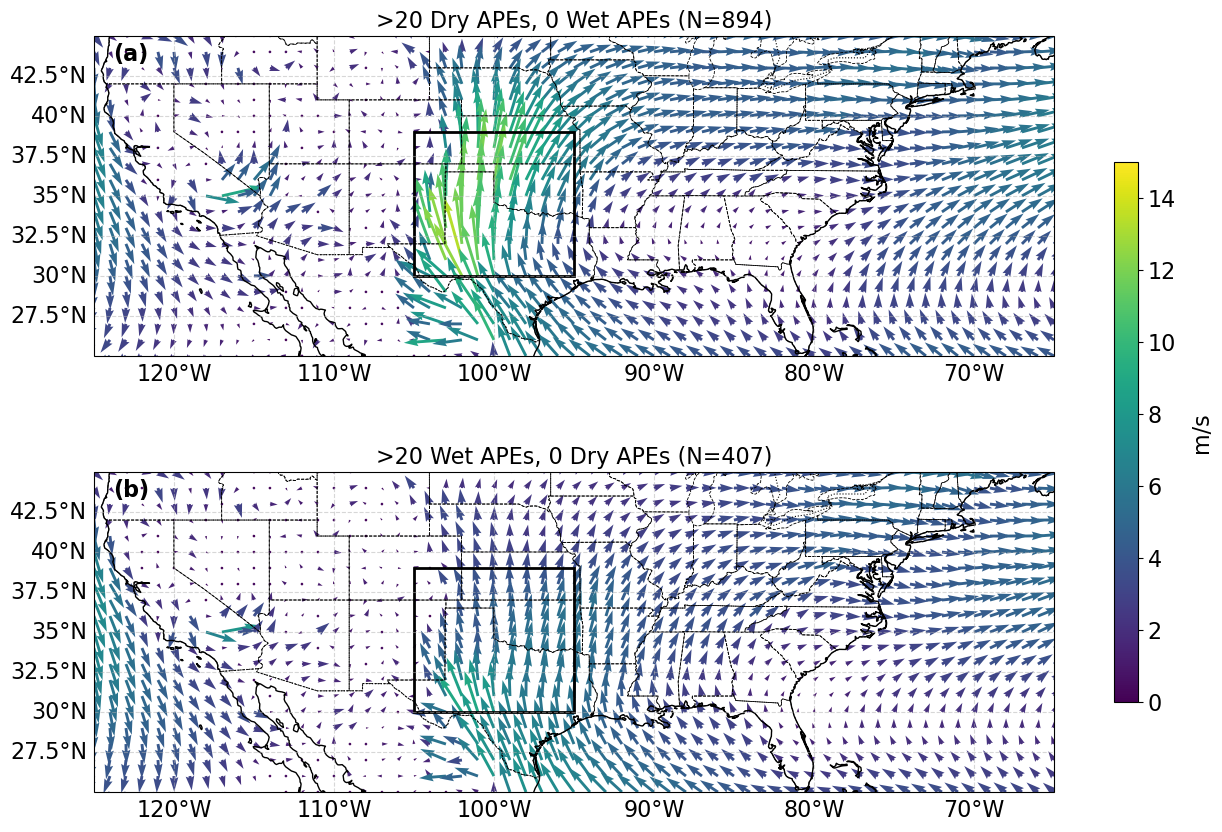

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
import textwrap

# ----------------------------
# Figure setup (match your formatting scheme)
# ----------------------------
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Colormap / normalization (wind speed coloring)
cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=15)

# Titles with N counts
titles = [
    f">{threshold_count} Dry APEs, 0 Wet APEs (N={category_counts[0]})",
    f">{threshold_count} Wet APEs, 0 Dry APEs (N={category_counts[1]})",
]

composites = [(u_comp_1, v_comp_1), (u_comp_2, v_comp_2)]
wind_magnitudes = wind_speeds[:2]  # first two categories only

# Grid/subsample
lons = winds_0lst_850["longitude"].values
lats = winds_0lst_850["latitude"].values
lon_grid, lat_grid = np.meshgrid(lons, lats)

lon_min, lon_max = np.min(lons), np.max(lons)
lat_min, lat_max = np.min(lats), np.max(lats)

quiver_step = 4

# Plot
for ax, (u_comp, v_comp), wind_speed, title in zip(axes, composites, wind_magnitudes, titles):

    # Match the map extent style you’ve been using
    ax.set_extent([lon_min, lon_max, lat_min, lat_max - 5], crs=ccrs.PlateCarree())

    u_sub = u_comp[::quiver_step, ::quiver_step]
    v_sub = v_comp[::quiver_step, ::quiver_step]
    ws_sub = wind_speed[::quiver_step, ::quiver_step]
    lon_sub = lon_grid[::quiver_step, ::quiver_step]
    lat_sub = lat_grid[::quiver_step, ::quiver_step]

    quiv = ax.quiver(
        lon_sub, lat_sub, u_sub, v_sub, ws_sub,
        transform=ccrs.PlateCarree(),
        scale=200, width=0.003,
        cmap=cmap, norm=norm
    )

    # Map features (match thicker/cleaner look)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)
    ax.add_feature(cfeature.STATES, linestyle="--", linewidth=0.6, edgecolor="black")

    # Gridlines (match your other figure)
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 16}
    gl.ylabel_style = {"size": 16}

    # SGP box
    sgp_lon_min, sgp_lon_max = -105, -95
    sgp_lat_min, sgp_lat_max = 30, 39
    box = Rectangle(
        (sgp_lon_min, sgp_lat_min),
        sgp_lon_max - sgp_lon_min,
        sgp_lat_max - sgp_lat_min,
        linewidth=2, edgecolor="black", facecolor="none",
        transform=ccrs.PlateCarree()
    )
    ax.add_patch(box)

    ax.set_title(title, fontsize=16)

# ----------------------------
# Colorbar (match your add_axes placement style)
# ----------------------------
cbar_ax = fig.add_axes([0.93, 0.36, 0.02, 0.45])
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation="vertical")
cbar.ax.tick_params(labelsize=16)
cbar.set_label("m/s", fontsize=16, labelpad=10, rotation=90)


# ----------------------------
# Caption (match Figure 5 style + add Ns)
# ----------------------------
n_dry = category_counts[0]
n_wet = category_counts[1]

raw_caption = (
    r'$\bf{Figure\ 6.}$ '
    f'Composite 850 hPa horizontal wind vectors (arrows) colored by wind speed for '
    f'days classified as (e) dry and (f) wet APE "preferred" regimes. '
    f'A dry (wet) APE "preferred" regime is defined as days in which > {threshold_count} dry (wet) APEs occurred '
    f'while 0 wet (dry) APEs occurred. '
    f'The number of days composited is n = {n_dry} for the dry regime and n = {n_wet} for the wet regime. '
    'The black box denotes the Southern Great Plains domain used in this study.'
)

caption = textwrap.fill(raw_caption, width=130)

bottom_margin = 0.25  # try 0.22–0.27

plt.subplots_adjust(
    left=0.08,
    right=0.88,
    top=0.95,
    bottom=bottom_margin,
    hspace=0.08
)

# fig.text(
#     0.5,
#     bottom_margin - 0.02,
#     caption,
#     ha="center",
#     va="top",
#     fontsize=14
# )

# ----------------------------
# Panel labels (bottom-left)
# ----------------------------
panel_labels = ["(a)", "(b)"]

for ax, lab in zip(axes, panel_labels):
    ax.text(
        0.02, 0.98,          # x=left, y=top
        lab,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
        fontsize=16
    )
    
fig.savefig("/home/annierosen16/winds.png", dpi=300, bbox_inches="tight")

plt.show()